<a href="https://colab.research.google.com/github/sevenZHQ1018/Econ5200/blob/lab/Class3_Lab3_hangqi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install World Bank API
!pip install wbgapi -q

import wbgapi as wb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print(" Libraries imported successfully")

 Libraries imported successfully


In [ ]:
# Define economies and indicators
country_codes = ['GTM', 'UMC', 'WLD']
# GTM = Guatemala
# UMC = Upper Middle Income countries
# WLD = World average

indicators = {
    'NY.GDP.PCAP.KD': 'GDP_Per_Capita_Const',      # Standard of Living
    'SL.TLF.CACT.ZS': 'Labor_Part_Rate',           # Labor Supply
    'SL.UEM.TOTL.ZS': 'Unemployment_Rate',         # Labor Friction
    'SL.TLF.TOTL.IN': 'Labor_Force_Total',         # Total Workers
    'NY.GDP.MKTP.KD': 'GDP_Const',                 # Economic Size
    'FP.CPI.TOTL.ZG': 'Inflation_CPI',             # Stability
    'NY.GDS.TOTL.ZS': 'Gross_Dom_Savings',         # Savings
    'NE.GDI.TOTL.ZS': 'Gross_Cap_Formation',       # Investment
    'NE.EXP.GNFS.ZS': 'Exports_GDP',               # Exports
    'NE.IMP.GNFS.ZS': 'Imports_GDP',               # Imports
    'GC.TAX.TOTL.GD.ZS': 'Tax_Rev_GDP',            # Gov Revenue
    'NE.CON.GOVT.ZS': 'Gov_Exp_GDP'                # Gov Spending
}

print("Countries:", country_codes)
print(f"Indicators: {len(indicators)} variables")

Countries: ['GTM', 'UMC', 'WLD']
Indicators: 12 variables


In [ ]:
# 1. Fetch Data
print("Fetching data from World Bank...")
df_raw = wb.data.DataFrame(indicators, economy=country_codes, time=range(2000, 2025))
print("✓ Data fetched")

# 2. Transpose (Flip Rows/Cols)
df = df_raw.T

# 3. Clean Index
df.index = df.index.str.replace('YR', '').astype(int)
df.index.name = 'Year'
df = df.sort_index()

# 4. Rename Columns
df.rename(columns=indicators, level=1, inplace=True)

print(f"✓ Data cleaned: {df.shape}")
print(f"Years: {df.index.min()} - {df.index.max()}")

Fetching data from World Bank...
✓ Data fetched
✓ Data cleaned: (25, 36)
Years: 2000 - 2024


In [ ]:
# 5. Extract Guatemala data
df_gtm = df.xs('GTM', axis=1, level=0).copy()
print("✓ Guatemala data extracted")
print(f"Shape: {df_gtm.shape}")
print(f"\nColumns: {list(df_gtm.columns)}")

✓ Guatemala data extracted
Shape: (25, 12)

Columns: ['Inflation_CPI', 'Tax_Rev_GDP', 'Gov_Exp_GDP', 'Exports_GDP', 'Gross_Cap_Formation', 'Imports_GDP', 'GDP_Const', 'GDP_Per_Capita_Const', 'Gross_Dom_Savings', 'Labor_Part_Rate', 'Labor_Force_Total', 'Unemployment_Rate']


In [ ]:
# 1. Natural Rate of Unemployment (5-Year MA)
df_gtm['Natural_Rate_Unemp'] = df_gtm['Unemployment_Rate'].rolling(window=5).mean()

# 2. Productivity (Output per Worker)
df_gtm['Productivity'] = df_gtm['GDP_Const'] / df_gtm['Labor_Force_Total']

# 3. Net Capital Outflow (Exports - Imports)
df_gtm['NCO'] = df_gtm['Exports_GDP'] - df_gtm['Imports_GDP']

# 4. Budget Balance (Tax - Spending)
df_gtm['Budget_Balance'] = df_gtm['Tax_Rev_GDP'] - df_gtm['Gov_Exp_GDP']

print("✓ All derived indicators calculated")

✓ All derived indicators calculated


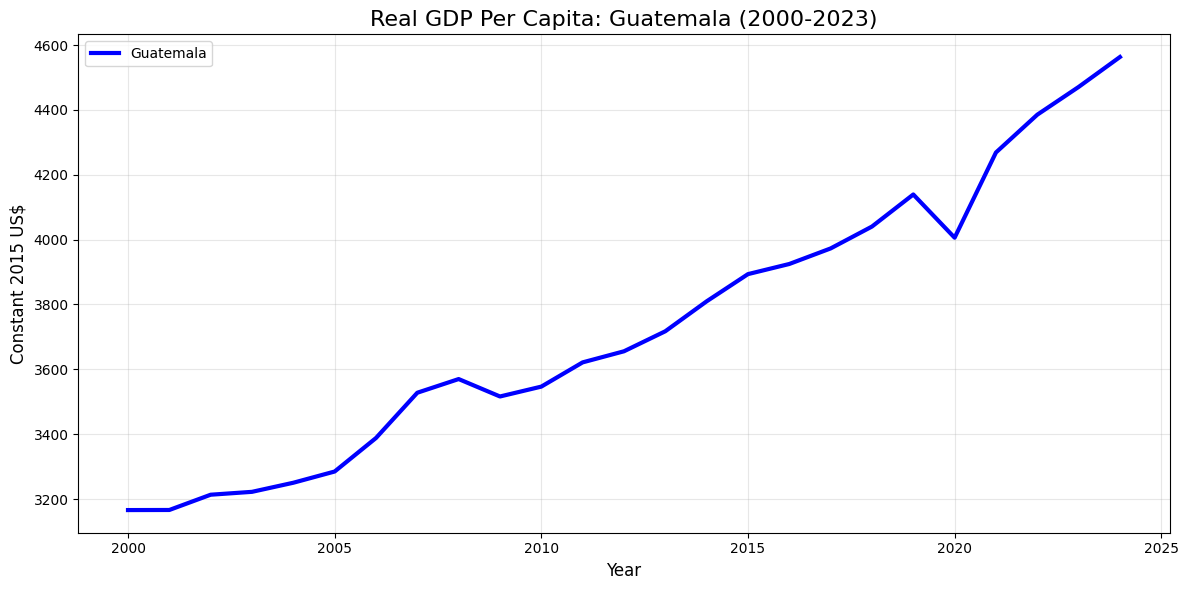

 Exercise 1 complete
Note: Line goes up - looks impressive! But is it?


In [ ]:
# Plot ONLY Guatemala
plt.figure(figsize=(12, 6))

plt.plot(df.index, df[('GTM', 'GDP_Per_Capita_Const')],
        label='Guatemala', color='blue', linewidth=3)

plt.title('Real GDP Per Capita: Guatemala (2000-2023)', fontsize=16)
plt.ylabel('Constant 2015 US$', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ex1_narrow_view.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Exercise 1 complete")
print("Note: Line goes up - looks impressive! But is it?")

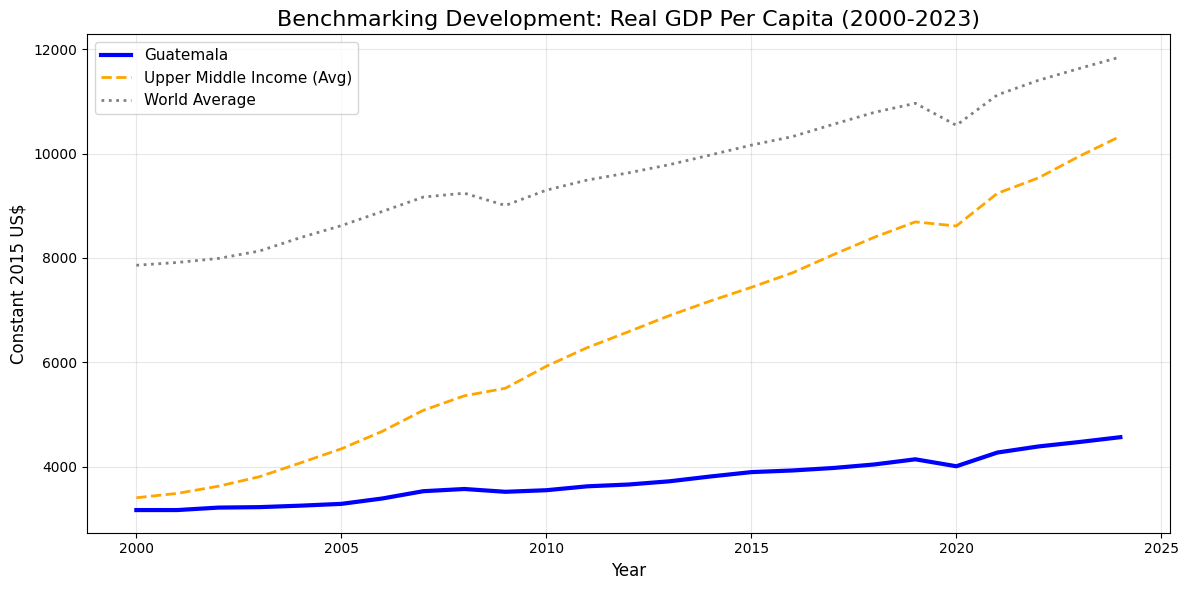

 Exercise 2 complete
Now the 'impressive' growth looks different!


In [ ]:
# Add context: Compare with UMC and World
plt.figure(figsize=(12, 6))

plt.plot(df.index, df[('GTM', 'GDP_Per_Capita_Const')],
        label='Guatemala', color='blue', linewidth=3)

# ADD BENCHMARKS
plt.plot(df.index, df[('UMC', 'GDP_Per_Capita_Const')],
        label='Upper Middle Income (Avg)', color='orange', linestyle='--', linewidth=2)

plt.plot(df.index, df[('WLD', 'GDP_Per_Capita_Const')],
        label='World Average', color='grey', linestyle=':', linewidth=2)

plt.title('Benchmarking Development: Real GDP Per Capita (2000-2023)', fontsize=16)
plt.ylabel('Constant 2015 US$', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ex2_benchmarking.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Exercise 2 complete")
print("Now the 'impressive' growth looks different!")

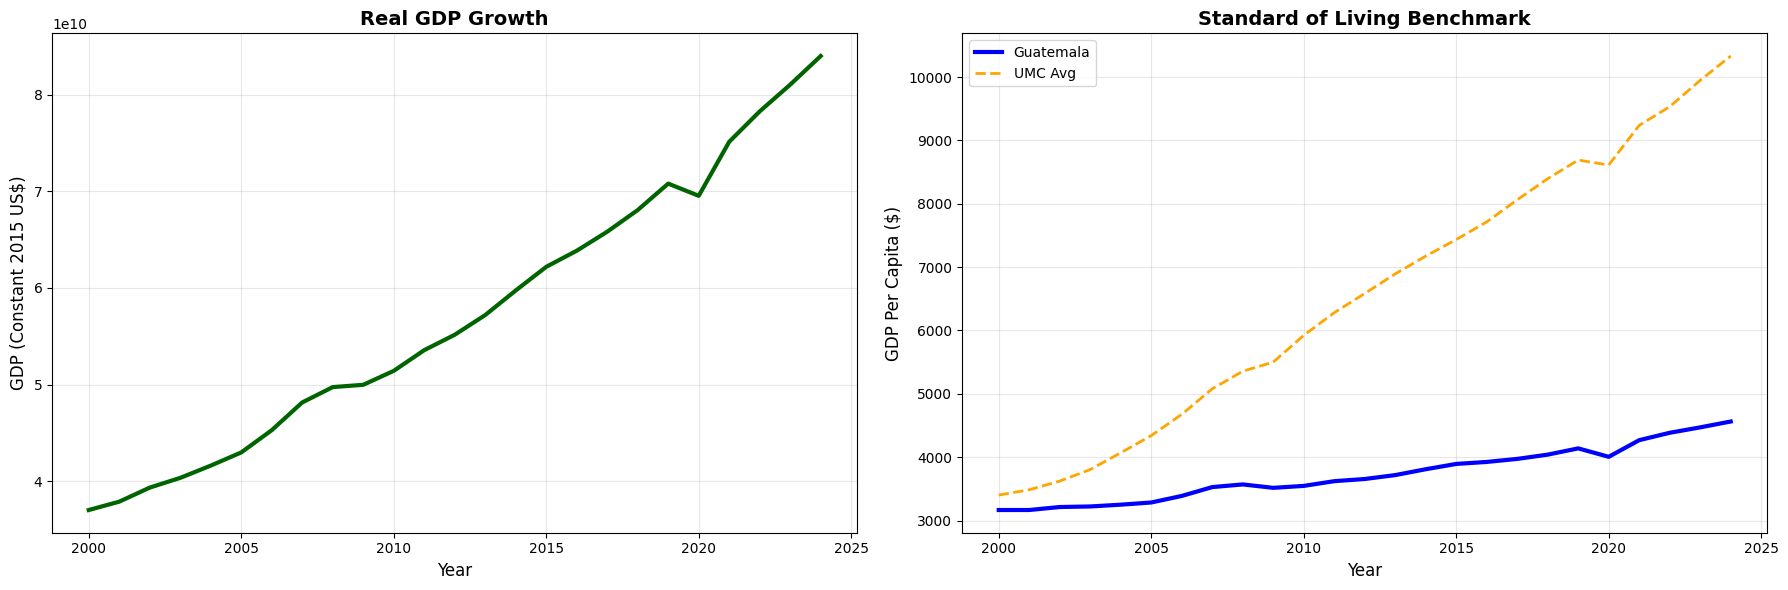

 Exercise 3 complete


In [ ]:
# Side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Chart A: Total GDP
sns.lineplot(data=df_gtm, x=df_gtm.index, y='GDP_Const',
            color='darkgreen', linewidth=3, ax=ax1)
ax1.set_title('Real GDP Growth', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('GDP (Constant 2015 US$)', fontsize=12)
ax1.grid(True, alpha=0.3)

# Chart B: GDP Per Capita Benchmark
ax2.plot(df.index, df[('GTM', 'GDP_Per_Capita_Const')],
        color='blue', linewidth=3, label='Guatemala')
ax2.plot(df.index, df[('UMC', 'GDP_Per_Capita_Const')],
        color='orange', linestyle='--', linewidth=2, label='UMC Avg')
ax2.set_title('Standard of Living Benchmark', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('GDP Per Capita ($)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ex3_wealth_vs_growth.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Exercise 3 complete")

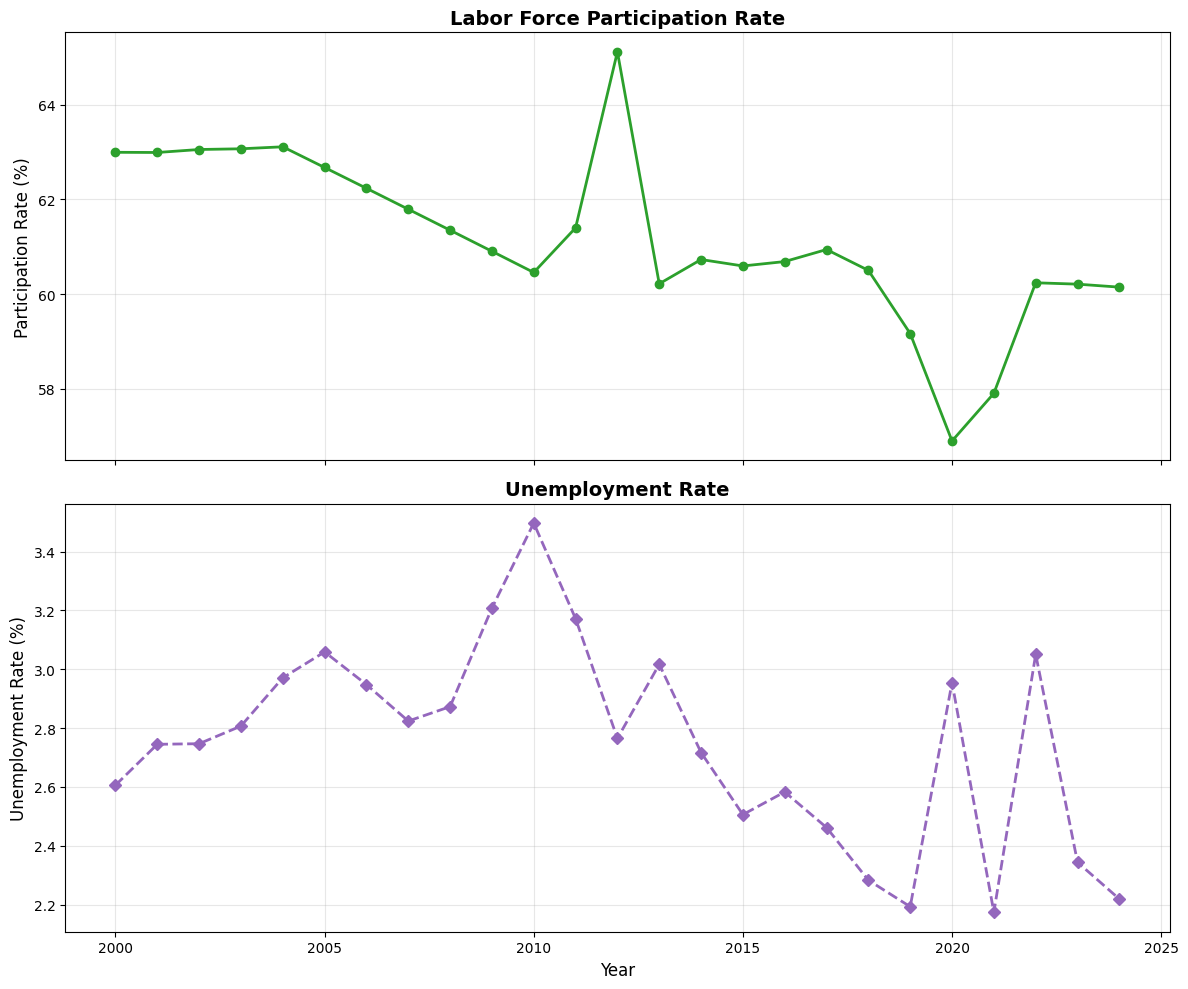

 Exercise 4 complete


In [ ]:
# Vertical stacked charts with shared x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Top: Participation Rate
ax1.plot(df_gtm.index, df_gtm['Labor_Part_Rate'],
        color='tab:green', marker='o', linewidth=2)
ax1.set_title('Labor Force Participation Rate', fontsize=14, fontweight='bold')
ax1.set_ylabel('Participation Rate (%)', fontsize=12)
ax1.grid(True, alpha=0.3)

# Bottom: Unemployment Rate
ax2.plot(df_gtm.index, df_gtm['Unemployment_Rate'],
        color='tab:purple', marker='D', linestyle='--', linewidth=2)
ax2.set_title('Unemployment Rate', fontsize=14, fontweight='bold')
ax2.set_ylabel('Unemployment Rate (%)', fontsize=12)
ax2.set_xlabel('Year', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ex4_labor_market.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Exercise 4 complete")

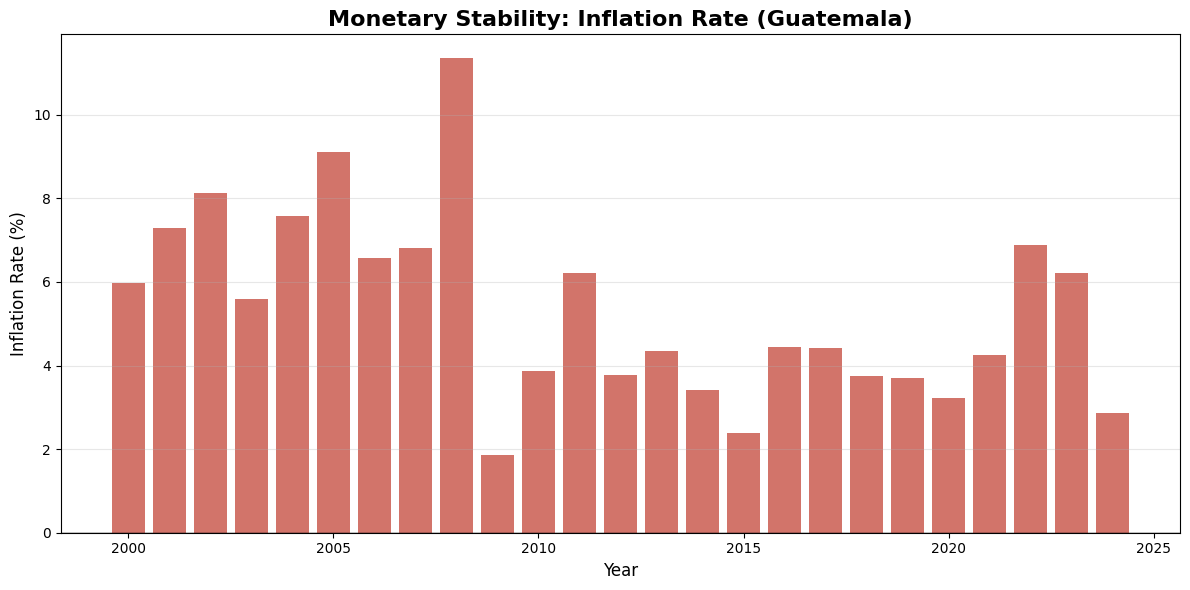

 Exercise 5 complete


In [ ]:
# Bar chart for inflation
plt.figure(figsize=(12, 6))

plt.bar(df_gtm.index, df_gtm['Inflation_CPI'], color='#c0392b', alpha=0.7)
plt.axhline(0, color='black', linewidth=1)

plt.title('Monetary Stability: Inflation Rate (Guatemala)', fontsize=16, fontweight='bold')
plt.ylabel('Inflation Rate (%)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('ex5_inflation.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Exercise 5 complete")

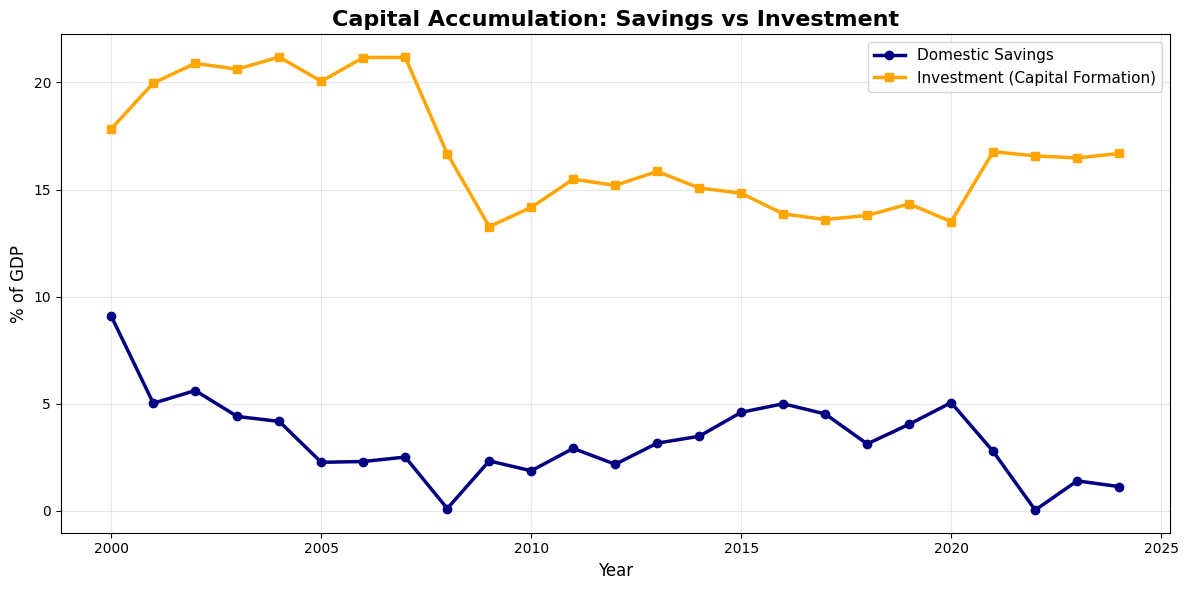

 Exercise 6 complete


In [ ]:
# Savings and Investment
plt.figure(figsize=(12, 6))

plt.plot(df_gtm.index, df_gtm['Gross_Dom_Savings'],
        label='Domestic Savings', color='navy', linewidth=2.5, marker='o')
plt.plot(df_gtm.index, df_gtm['Gross_Cap_Formation'],
        label='Investment (Capital Formation)', color='orange', linewidth=2.5, marker='s')

plt.title('Capital Accumulation: Savings vs Investment', fontsize=16, fontweight='bold')
plt.ylabel('% of GDP', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ex6_savings_investment.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Exercise 6 complete")

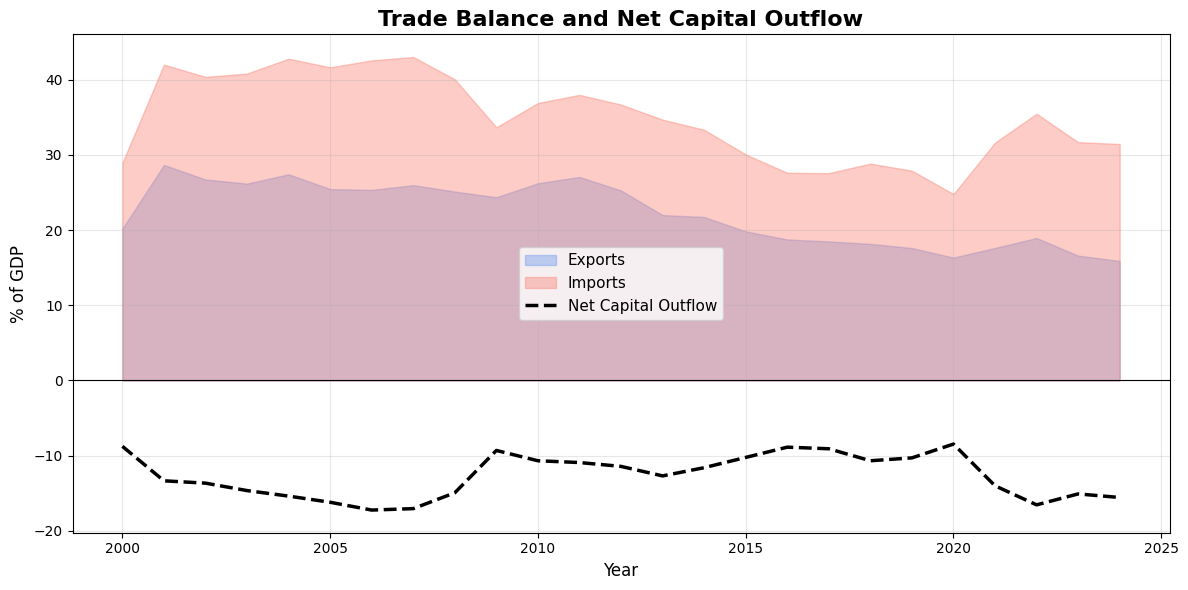

 Exercise 7 complete


In [ ]:
# Trade balance with fill_between
plt.figure(figsize=(12, 6))

plt.fill_between(df_gtm.index, df_gtm['Exports_GDP'],
                color='cornflowerblue', alpha=0.4, label='Exports')
plt.fill_between(df_gtm.index, df_gtm['Imports_GDP'],
                color='salmon', alpha=0.4, label='Imports')
plt.plot(df_gtm.index, df_gtm['NCO'],
        color='black', linestyle='--', linewidth=2.5, label='Net Capital Outflow')

plt.title('Trade Balance and Net Capital Outflow', fontsize=16, fontweight='bold')
plt.ylabel('% of GDP', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('ex7_trade_balance.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Exercise 7 complete")

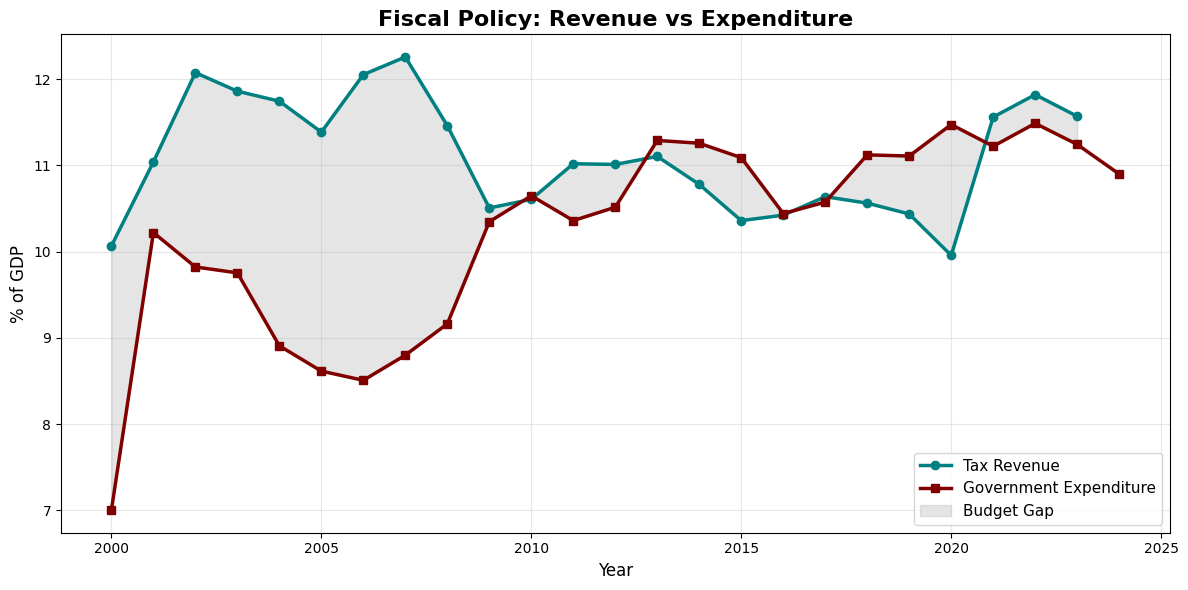

 Exercise 8 complete


In [ ]:
# Fiscal balance (Tax vs Spending)
plt.figure(figsize=(12, 6))

plt.plot(df_gtm.index, df_gtm['Tax_Rev_GDP'],
        label='Tax Revenue', color='teal', linewidth=2.5, marker='o')
plt.plot(df_gtm.index, df_gtm['Gov_Exp_GDP'],
        label='Government Expenditure', color='maroon', linewidth=2.5, marker='s')

# Fill structural gap
plt.fill_between(df_gtm.index, df_gtm['Tax_Rev_GDP'], df_gtm['Gov_Exp_GDP'],
                color='gray', alpha=0.2, label='Budget Gap')

plt.title('Fiscal Policy: Revenue vs Expenditure', fontsize=16, fontweight='bold')
plt.ylabel('% of GDP', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ex8_fiscal_policy.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Exercise 8 complete")

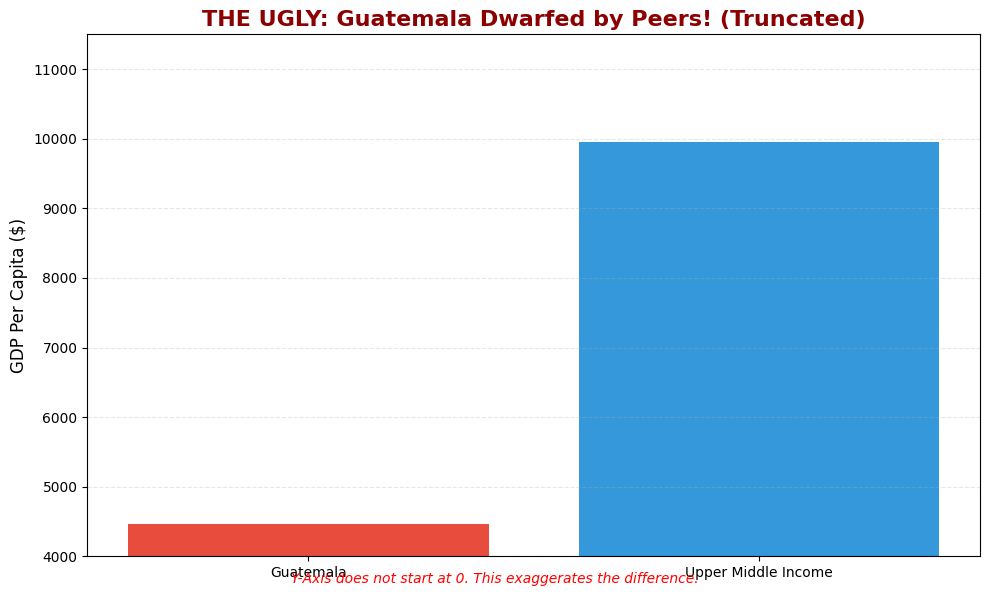

UGLY chart complete
Actual values: Guatemala=$4,471, UMC=$9,949
Ratio: 2.23x (not as dramatic as the chart suggests!)


In [ ]:
# THE UGLY CHART - Truncated axis
snapshot_year = 2023
gtm_val = df.loc[snapshot_year, ('GTM', 'GDP_Per_Capita_Const')]
umc_val = df.loc[snapshot_year, ('UMC', 'GDP_Per_Capita_Const')]

values = [gtm_val, umc_val]
labels = ['Guatemala', 'Upper Middle Income']

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=['#e74c3c', '#3498db'])

# THE VIOLATION: Truncating the axis
plt.ylim(4000, 11500)  # Should start at 0!

plt.title('THE UGLY: Guatemala Dwarfed by Peers! (Truncated)',
         fontsize=16, fontweight='bold', color='darkred')
plt.ylabel('GDP Per Capita ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.figtext(0.5, 0.02,
           "Y-Axis does not start at 0. This exaggerates the difference.",
           ha="center", style='italic', fontsize=10, color='red')

plt.tight_layout()
plt.savefig('ugly_truncated_axis.png', dpi=300, bbox_inches='tight')
plt.show()

print("UGLY chart complete")
print(f"Actual values: Guatemala=${gtm_val:,.0f}, UMC=${umc_val:,.0f}")
print(f"Ratio: {umc_val/gtm_val:.2f}x (not as dramatic as the chart suggests!)")

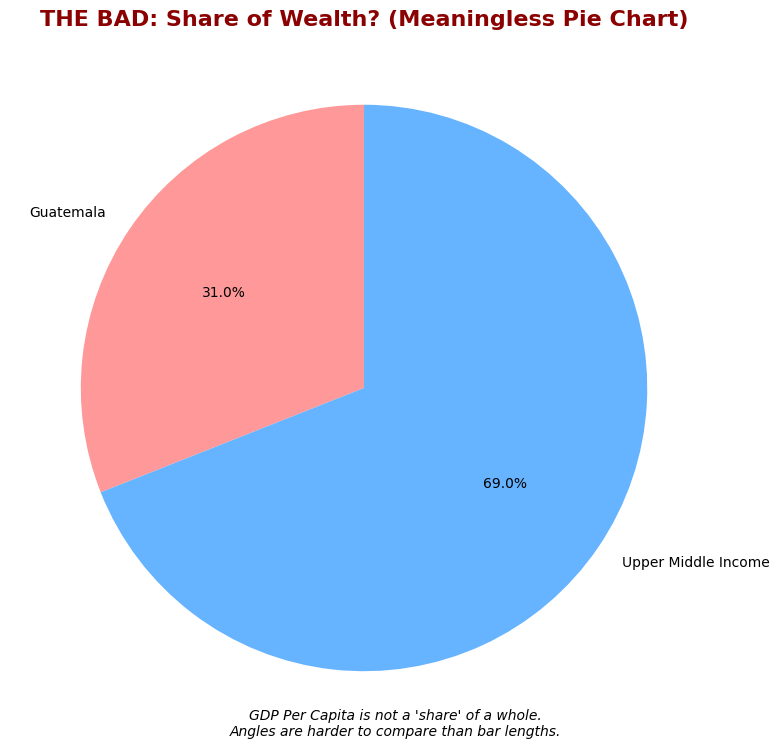

BAD chart complete
Why is this bad? GDP per capita is a comparison, not parts of a whole!


In [ ]:
# THE BAD CHART - Pie chart for non-summable data
plt.figure(figsize=(8, 8))

# THE VIOLATION: Pie chart for GDP Per Capita (not shares!)
plt.pie(values, labels=labels, autopct='%1.1f%%',
       colors=['#ff9999','#66b3ff'], startangle=90)

plt.title('THE BAD: Share of Wealth? (Meaningless Pie Chart)',
         fontsize=16, fontweight='bold', color='darkred')

plt.figtext(0.5, 0.05,
           "GDP Per Capita is not a 'share' of a whole.\n" +
           "Angles are harder to compare than bar lengths.",
           ha="center", style='italic', fontsize=10)

plt.tight_layout()
plt.savefig('bad_pie_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print("BAD chart complete")
print("Why is this bad? GDP per capita is a comparison, not parts of a whole!")

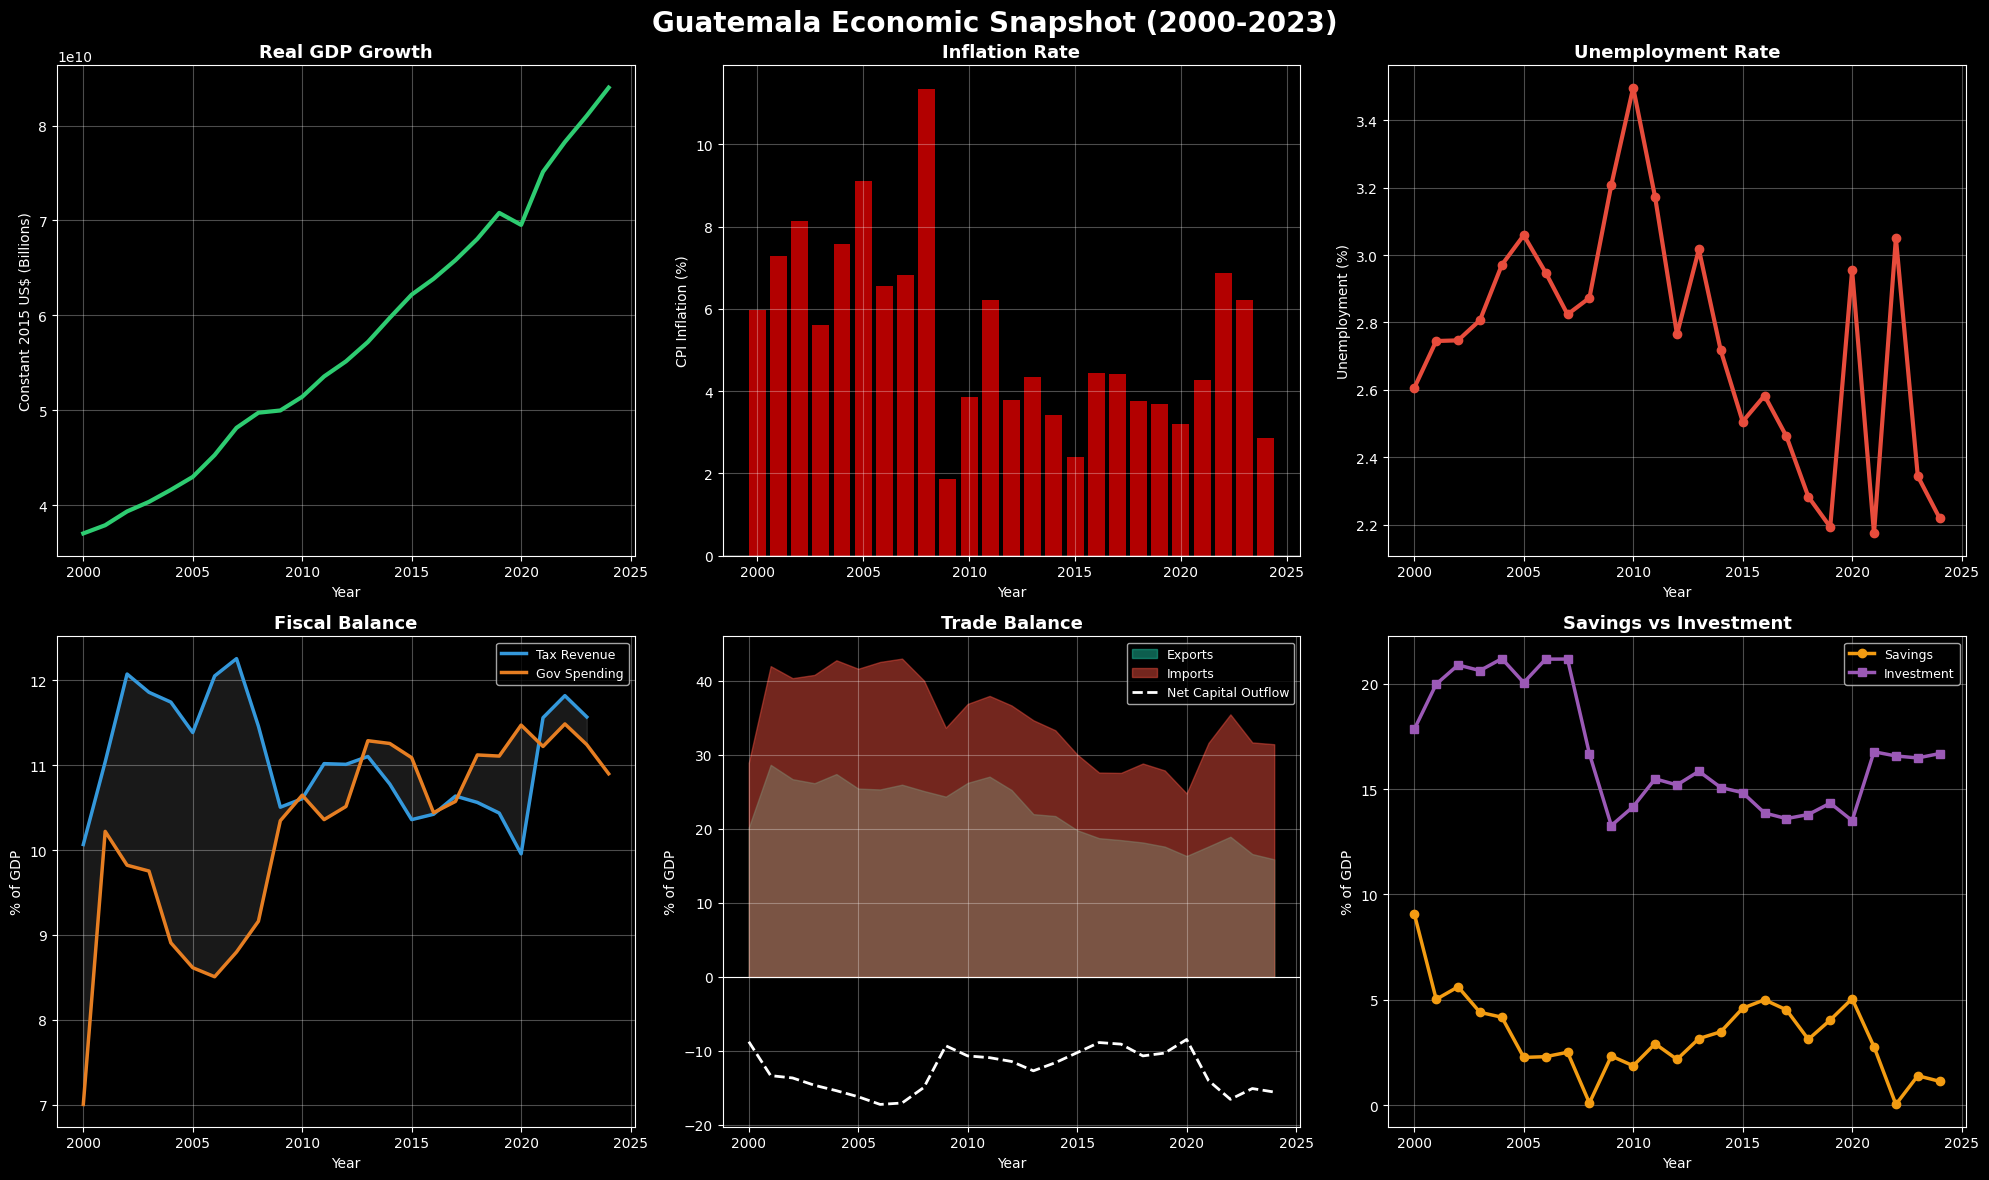

 Executive Dashboard complete


In [ ]:
# AI-Generated Executive Dashboard
# Using dark background for professional look

plt.style.use('dark_background')
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Guatemala Economic Snapshot (2000-2023)',
            fontsize=20, fontweight='bold', y=0.98)

# Top Left: Real GDP
axes[0, 0].plot(df_gtm.index, df_gtm['GDP_Const'], color='#2ecc71', linewidth=3)
axes[0, 0].set_title('Real GDP Growth', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Constant 2015 US$ (Billions)', fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Top Middle: Inflation
colors = ['red' if x > 0 else 'green' for x in df_gtm['Inflation_CPI']]
axes[0, 1].bar(df_gtm.index, df_gtm['Inflation_CPI'], color=colors, alpha=0.7)
axes[0, 1].axhline(0, color='white', linewidth=1)
axes[0, 1].set_title('Inflation Rate', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('CPI Inflation (%)', fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# Top Right: Unemployment
axes[0, 2].plot(df_gtm.index, df_gtm['Unemployment_Rate'],
               color='#e74c3c', linewidth=3, marker='o')
axes[0, 2].set_title('Unemployment Rate', fontsize=13, fontweight='bold')
axes[0, 2].set_ylabel('Unemployment (%)', fontsize=10)
axes[0, 2].grid(True, alpha=0.3)

# Bottom Left: Fiscal Balance
axes[1, 0].plot(df_gtm.index, df_gtm['Tax_Rev_GDP'],
               label='Tax Revenue', color='#3498db', linewidth=2.5)
axes[1, 0].plot(df_gtm.index, df_gtm['Gov_Exp_GDP'],
               label='Gov Spending', color='#e67e22', linewidth=2.5)
axes[1, 0].fill_between(df_gtm.index, df_gtm['Tax_Rev_GDP'], df_gtm['Gov_Exp_GDP'],
                       alpha=0.2, color='gray')
axes[1, 0].set_title('Fiscal Balance', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('% of GDP', fontsize=10)
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, alpha=0.3)

# Bottom Middle: Trade Balance
axes[1, 1].fill_between(df_gtm.index, df_gtm['Exports_GDP'],
                       alpha=0.5, color='#1abc9c', label='Exports')
axes[1, 1].fill_between(df_gtm.index, df_gtm['Imports_GDP'],
                       alpha=0.5, color='#e74c3c', label='Imports')
axes[1, 1].plot(df_gtm.index, df_gtm['NCO'],
               color='white', linestyle='--', linewidth=2, label='Net Capital Outflow')
axes[1, 1].axhline(0, color='white', linewidth=0.8)
axes[1, 1].set_title('Trade Balance', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('% of GDP', fontsize=10)
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, alpha=0.3)

# Bottom Right: Savings vs Investment
axes[1, 2].plot(df_gtm.index, df_gtm['Gross_Dom_Savings'],
               label='Savings', color='#f39c12', linewidth=2.5, marker='o')
axes[1, 2].plot(df_gtm.index, df_gtm['Gross_Cap_Formation'],
               label='Investment', color='#9b59b6', linewidth=2.5, marker='s')
axes[1, 2].set_title('Savings vs Investment', fontsize=13, fontweight='bold')
axes[1, 2].set_ylabel('% of GDP', fontsize=10)
axes[1, 2].legend(fontsize=9)
axes[1, 2].grid(True, alpha=0.3)

# Format all x-axes
for ax in axes.flat:
    ax.set_xlabel('Year', fontsize=10)

plt.tight_layout()
plt.savefig('executive_dashboard.png', dpi=300, bbox_inches='tight', facecolor='#2c3e50')
plt.show()

# Reset style
plt.style.use('default')

print(" Executive Dashboard complete")